In [1]:
# If you are running on Google Colab, UNCOMMENT this block.
'''
# ── Google Drive mount ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")
'''

Mounted at /content/drive


In [22]:
# =============================================================================
# IMPORTS, PATHS, CONSTANTS
# =============================================================================

from pathlib import Path
from collections import Counter
from typing import Dict, List, Tuple, Any

import json
import random
import time
import warnings

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import mannwhitneyu
from tqdm import tqdm, trange
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings("ignore")

if not hasattr(np, "bool8"):
    np.bool8 = np.bool_

# =============================================================================
# EXPERIMENT SETTINGS
# =============================================================================

MASTER_SEED = 42

# for faster run NUM_RUNS=1, EPISODE_BUDGET= 100. for paper results replication, set (NUM_RUNS=10, EPISODE_BUDGET= 1500)

NUM_RUNS = 10

EPISODE_BUDGET = 1500

BASE_SEED_START = 5000

EPSILON = 0.01

MAX_STEPS = 35

random.seed(MASTER_SEED)
np.random.seed(MASTER_SEED)

# =============================================================================
# PATHS
# =============================================================================

ROOT = Path("/content/drive/MyDrive/mbrl-testing-frameworks-empirical-study")

AGENT_PATH = ROOT / "agents" / "dynaq" / "windy"

RESULTS_DIR = ROOT / "results" / "windy"

RAW_DIR = RESULTS_DIR / "raw"
TABLES_DIR = RESULTS_DIR / "tables"
FIGS_DIR = RESULTS_DIR / "figs"

for p in [RESULTS_DIR, RAW_DIR, TABLES_DIR, FIGS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Agent:", AGENT_PATH)
print("Results:", RESULTS_DIR)

Agent: /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/agents/dynaq/windy
Results: /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/results/windy


In [23]:
# =============================================================================
# STOCHASTIC WINDY GRIDWORLD
# =============================================================================

from gymnasium import spaces

SW_ROWS = 7
SW_COLS = 10

SW_N_STATES = 70
SW_N_ACTIONS = 4

SW_WIND = np.array(
    [0,0,0,1,1,1,2,2,1,0],
    dtype=int,
)

SW_GOAL = (3, 7)

SW_GOAL_STATE = (
    SW_GOAL[0] * SW_COLS
    + SW_GOAL[1]
)


class StochasticWindyGridworldEnv(gym.Env):

    metadata = {"render_modes": []}

    def __init__(self):

        super().__init__()

        self.rows = SW_ROWS
        self.cols = SW_COLS

        self.wind = SW_WIND.copy()

        self.goal = SW_GOAL

        self.action_space = spaces.Discrete(
            SW_N_ACTIONS
        )

        self.observation_space = spaces.Discrete(
            SW_N_STATES
        )

        self.state = (0, 0)

        self._np_rng = np.random.default_rng(0)

    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        if seed is not None:
            self._np_rng = np.random.default_rng(seed)

        while True:

            r = int(
                self._np_rng.integers(0, SW_ROWS)
            )

            c = int(
                self._np_rng.integers(0, SW_COLS)
            )

            if (r, c) != self.goal:
                break

        self.state = (r, c)

        return self._encode(self.state), {}

    def step(self, action):

        r, c = self.state

        if action == 0:
            r -= 1
        elif action == 1:
            c += 1
        elif action == 2:
            r += 1
        elif action == 3:
            c -= 1

        r = int(np.clip(r, 0, SW_ROWS - 1))
        c = int(np.clip(c, 0, SW_COLS - 1))

        wind_noise = int(
            self._np_rng.choice([-1, 0, 1])
        )

        wind_push = int(
            max(0, self.wind[c] + wind_noise)
        )

        r = int(
            np.clip(
                r - wind_push,
                0,
                SW_ROWS - 1,
            )
        )

        self.state = (r, c)

        if self.state == self.goal:

            return (
                self._encode(self.state),
                0.0,
                True,
                False,
                {},
            )

        return (
            self._encode(self.state),
            -1.0,
            False,
            False,
            {},
        )

    def _encode(self, pos):

        return (
            pos[0] * SW_COLS
            + pos[1]
        )


def make_windy():

    return StochasticWindyGridworldEnv()


# =============================================================================
# LOAD AGENT
# =============================================================================

Q = np.load(
    AGENT_PATH / "dynaq_Q_windy.npy"
)

assert Q.shape == (70, 4)

N_STATES = Q.shape[0]
N_ACTIONS = Q.shape[1]

print("Q-table:", Q.shape)

Q-table: (70, 4)


In [24]:
# =============================================================================
# UTILITIES
# =============================================================================

def sw_encode(row, col):

    return row * SW_COLS + col


def sw_decode(state):

    return (
        state // SW_COLS,
        state % SW_COLS,
    )


def sw_random_state(rng):

    while True:

        row = int(
            rng.integers(0, SW_ROWS)
        )

        col = int(
            rng.integers(0, SW_COLS)
        )

        if (row, col) != SW_GOAL:

            return sw_encode(
                row,
                col,
            )


# =============================================================================
# EPISODE EXECUTION
# =============================================================================

def run_episode(
    initial_state,
    seed,
    epsilon=EPSILON,
):

    env = make_windy()

    env.reset(seed=int(seed))

    env.state = (
        initial_state // SW_COLS,
        initial_state % SW_COLS,
    )

    rng = np.random.default_rng(seed)

    state = int(initial_state)

    total = 0.0
    steps = 0

    done = False

    t0 = time.perf_counter()

    while not done and steps < MAX_STEPS:

        if rng.random() < epsilon:

            action = int(
                rng.integers(
                    0,
                    SW_N_ACTIONS,
                )
            )

        else:

            action = int(
                np.argmax(Q[state])
            )

        next_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated

        total += float(reward)

        state = int(next_state)

        steps += 1

    elapsed = time.perf_counter() - t0

    env.close()

    return {
        "return": float(total),
        "failure": int(not done),
        "steps": int(steps),
        "time": float(elapsed),
    }


# =============================================================================
# METRICS
# =============================================================================

def compute_metrics(df, tcp_time=0.0):

    failures = df["failure"].values.astype(int)
    times = df["time"].values.astype(float)

    n = len(failures)

    total_failures = int(np.sum(failures))

    FR = total_failures / n

    if total_failures > 0:

        first_idx = np.where(
            failures == 1
        )[0][0]

        TTF_tests = first_idx + 1

        TTF_time = np.sum(
            times[:first_idx + 1]
        )

    else:

        TTF_tests = np.nan
        TTF_time = np.nan

    if total_failures > 0:

        positions = (
            np.where(failures == 1)[0] + 1
        )

        APFD = (
            1
            - np.sum(positions)
            / (n * total_failures)
            + 1 / (2 * n)
        )

    else:

        APFD = np.nan

    if total_failures > 0:

        cum_time = np.cumsum(times)

        fail_times = cum_time[
            np.where(failures == 1)[0]
        ]

        total_time = cum_time[-1]

        APFD_time = (
            1
            - np.sum(fail_times)
            / (total_time * total_failures)
            + 1 / (2 * total_time)
        )

    else:

        APFD_time = np.nan

    return {
        "FR": float(FR),
        "TTF_tests": float(TTF_tests),
        "TTF_time": float(TTF_time),
        "APFD": float(APFD),
        "APFD_time": float(APFD_time),
        "TCP_time": float(tcp_time),
        "Per_test_overhead": float(
            tcp_time / n
        ),
    }

In [25]:
# =============================================================================
# TCP SIGNALS
# =============================================================================

def softmax(q, tau=1.0):

    q = q / tau

    q = q - np.max(q)

    e = np.exp(q)

    return e / np.sum(e)


def annotate_pool_returns(pool):

    annotated = []

    for t in pool:

        res = run_episode(
            initial_state=int(t["initial_state"]),
            seed=int(t["seed"]),
            epsilon=0.0,
        )

        annotated.append({
            **t,
            "return": float(res["return"]),
        })

    return annotated


def tcp_fifo(pool, **_):
    return sorted(pool, key=lambda x: x["episode_id"])


def tcp_random(pool, seed=MASTER_SEED, **_):

    rng = np.random.default_rng(seed)

    shuffled = pool.copy()

    rng.shuffle(shuffled)

    return shuffled


def tcp_entropy(pool, Q, **_):

    scored = []

    for t in pool:

        probs = softmax(
            Q[int(t["initial_state"])]
        )

        entropy = float(
            -np.sum(
                probs * np.log(
                    probs + 1e-12
                )
            )
        )

        scored.append({
            **t,
            "score": entropy,
        })

    return sorted(
        scored,
        key=lambda x: x["score"],
        reverse=True,
    )


def tcp_margin(pool, Q, **_):

    scored = []

    for t in pool:

        q_sorted = np.sort(
            Q[int(t["initial_state"])]
        )[::-1]

        margin = float(
            q_sorted[0] - q_sorted[1]
        )

        scored.append({
            **t,
            "score": margin,
        })

    return sorted(
        scored,
        key=lambda x: x["score"],
    )


def tcp_confidence(pool, Q, **_):

    scored = []

    for t in pool:

        probs = softmax(
            Q[int(t["initial_state"])]
        )

        confidence = float(
            np.max(probs)
        )

        scored.append({
            **t,
            "score": confidence,
        })

    return sorted(
        scored,
        key=lambda x: x["score"],
    )


def tcp_value_return_gap(pool, Q, **_):

    pool = annotate_pool_returns(
        pool
    )

    scored = []

    for t in pool:

        s = int(t["initial_state"])

        predicted = float(
            np.max(Q[s])
        )

        observed = float(
            t["return"]
        )

        gap = abs(
            predicted - observed
        )

        scored.append({
            **t,
            "score": gap,
        })

    return sorted(
        scored,
        key=lambda x: x["score"],
        reverse=True,
    )


def tcp_q_variance(pool, Q, **_):

    scored = []

    for t in pool:

        variance = float(
            np.var(
                Q[int(t["initial_state"])]
            )
        )

        scored.append({
            **t,
            "score": variance,
        })

    return sorted(
        scored,
        key=lambda x: x["score"],
        reverse=True,
    )


def tcp_state_novelty(pool, **_):

    counts = Counter(
        int(t["initial_state"])
        for t in pool
    )

    scored = []

    for t in pool:

        novelty = (
            1.0 /
            counts[
                int(t["initial_state"])
            ]
        )

        scored.append({
            **t,
            "score": novelty,
        })

    return sorted(
        scored,
        key=lambda x: x["score"],
        reverse=True,
    )


TCP_REGISTRY = {
    "FIFO": tcp_fifo,
    "Random": tcp_random,
    "Entropy": tcp_entropy,
    "Margin": tcp_margin,
    "Confidence": tcp_confidence,
    "ValueReturnGap": tcp_value_return_gap,
    "QVariance": tcp_q_variance,
    "StateNovelty": tcp_state_novelty,
}

In [26]:
# =============================================================================
# PHASE 1 — TCP ONLY
# =============================================================================

def generate_random_pool(
    base_seed,
    budget=EPISODE_BUDGET,
):

    pool = []

    for i in range(budget):

        seed = int(base_seed + i)

        rng = np.random.default_rng(seed)

        state = sw_random_state(rng)

        pool.append({
            "episode_id": i,
            "seed": seed,
            "initial_state": int(state),
        })

    return pool


def apply_tcp(
    pool,
    tcp_name,
    run_seed,
):

    func = TCP_REGISTRY[tcp_name]

    kwargs = {}

    if tcp_name != "FIFO":
        kwargs["Q"] = Q

    if tcp_name == "Random":
        kwargs["seed"] = run_seed

    start = time.perf_counter()

    ordered = func(pool, **kwargs)

    tcp_time = time.perf_counter() - start

    return ordered, tcp_time


def evaluate_phase1_pool(
    ordered_pool,
    tcp_time,
):

    rows = []

    for test in ordered_pool:

        result = run_episode(
            initial_state=int(test["initial_state"]),
            seed=int(test["seed"]),
            epsilon=EPSILON,
        )

        rows.append(result)

    df = pd.DataFrame(rows)

    metrics = compute_metrics(
        df,
        tcp_time=tcp_time,
    )

    return metrics


def run_phase1_single_run(
    run_id,
    base_seed,
):

    print(
        f"\nPhase 1 | Run {run_id + 1} "
        f"(seed={base_seed})"
    )

    pool = generate_random_pool(
        base_seed=base_seed,
        budget=EPISODE_BUDGET,
    )

    rows = []

    for tcp_name in TCP_REGISTRY:

        ordered_pool, tcp_time = apply_tcp(
            pool,
            tcp_name,
            base_seed,
        )

        metrics = evaluate_phase1_pool(
            ordered_pool,
            tcp_time,
        )

        row = {
            "run_id": run_id,
            "TCP": tcp_name,
        }

        row.update(metrics)

        rows.append(row)

        print(
            f"{tcp_name:<18}"
            f"APFD={metrics['APFD']:.4f}"
        )

    return rows


def run_phase1(
    num_runs=NUM_RUNS,
):

    all_rows = []

    for run_id in range(num_runs):

        base_seed = (
            BASE_SEED_START
            + run_id * 10000
        )

        rows = run_phase1_single_run(
            run_id,
            base_seed,
        )

        all_rows.extend(rows)

    results = pd.DataFrame(all_rows)

    results.to_csv(
        TABLES_DIR / "phase1_results.csv",
        index=False,
    )

    return results


def summarize_phase1(results):

    metrics = [
        "FR",
        "TTF_tests",
        "TTF_time",
        "APFD",
        "APFD_time",
        "TCP_time",
        "Per_test_overhead",
    ]

    agg = (
        results
        .groupby("TCP")[metrics]
        .agg(["mean", "std"])
        .round(6)
    )

    agg.columns = [
        "_".join(c)
        for c in agg.columns
    ]

    agg = agg.reset_index()

    agg.to_csv(
        TABLES_DIR / "phase1_aggregate.csv",
        index=False,
    )

    return agg

In [27]:
def _sw_bd(state: int) -> Tuple[int, int, int]:
    """
    Behaviour descriptor:
      row band, column band, wind strength.
    """
    row, col = sw_decode(state)

    row_band = int(row)
    col_band = int(col // 2)
    wind_band = int(SW_WIND[col])

    return (row_band, col_band, wind_band)


def _sw_bd_cell(bd: Tuple[int, int, int]) -> Tuple[int, int, int]:
    return bd

def sw_manhattan(s_a: int, s_b: int) -> int:
    """Manhattan distance between two flat state indices."""
    r_a, c_a = sw_decode(s_a)
    r_b, c_b = sw_decode(s_b)
    return abs(r_a - r_b) + abs(c_a - c_b)

def _sw_eval_state_fast(state: int, seed: int) -> Tuple[float, int, int]:
    res = run_episode(initial_state=state, seed=seed, epsilon=0.0,)
    return float(res["return"]), int(res["steps"]), int(res["failure"])


def _sw_risk_proxy(state: int) -> float:
    q_row = Q[int(state)]
    q_sorted = np.sort(q_row)[::-1]
    q_gap = float(q_sorted[0] - q_sorted[1])
    probs = softmax(q_row)
    entropy = float(-np.sum(probs * np.log(probs + 1e-12)))

    dist = sw_manhattan(state, SW_GOAL_STATE)
    _, col = sw_decode(state)
    wind = float(SW_WIND[col])

    return float(entropy + (1.0 / (q_gap + 1e-6)) + 0.25 * dist + wind)

def sw_mutate_state(state: int, rng: np.random.Generator) -> int:
    """
    Grid-based mutation:
      row, col = sw_decode(state)
      Perturb row/col by ±1 or 0, clamped to valid grid bounds.
    """
    row, col = sw_decode(state)
    dr = int(rng.choice([-1, 0, 1]))
    dc = int(rng.choice([-1, 0, 1]))
    new_row = int(np.clip(row + dr, 0, SW_ROWS - 1))
    new_col = int(np.clip(col + dc, 0, SW_COLS - 1))
    if (new_row, new_col) == SW_GOAL:
        return sw_random_state(rng)
    return sw_encode(new_row, new_col)

def evaluate_ordered_pool(
    ordered_pool,
    tcp_time,
):
    rows = []

    for test in ordered_pool:
        result = run_episode(
            initial_state=int(test["initial_state"]),
            seed=int(test["seed"]),
            epsilon=EPSILON,
        )

        # ✅ FIX: include initial_state
        rows.append({
            "initial_state": int(test["initial_state"]),
            "return": result["return"],
            "failure": result["failure"],
            "steps": result["steps"],
            "time": result["time"]
        })

    df = pd.DataFrame(rows)



    metrics = compute_metrics(df, tcp_time=tcp_time)

    return df, metrics
# ==============================================================================
# FRAMEWORK: INDAGO
# ==============================================================================
#
# Literature (Perez et al.):
#   Large candidate pool → label subset → train RandomForest →
#   rank all candidates by failure probability → keep top-K.
#
# Windy adaptation:
#   Features: row, col, dist_to_goal, wind_at_col, q_max, q_var, q_gap, entropy.
#   All states are valid (no walls); only the goal is excluded as a start.

def _sw_indago_features(state: int) -> List[float]:
    row, col = sw_decode(state)
    dist_goal = sw_manhattan(state, SW_GOAL_STATE)
    wind_col = float(SW_WIND[col])

    q_row = Q[state]
    q_max = float(np.max(q_row))
    q_var = float(np.var(q_row))
    q_sorted = np.sort(q_row)[::-1]
    q_gap = float(q_sorted[0] - q_sorted[1])
    probs = softmax(q_row)
    entropy = float(-np.sum(probs * np.log(probs + 1e-12)))

    return [
        float(row),
        float(col),
        float(dist_goal),
        float(wind_col),
        q_max,
        q_var,
        q_gap,
        entropy,
    ]


def generate_tests_indago(
    base_seed: int,
    budget: int = EPISODE_BUDGET,
    pool_size: int = 6000,
    train_size: int = 1200,
) -> List[Dict]:


    rng = np.random.default_rng(base_seed)

    pool = []
    for i in range(pool_size):
        seed = int(base_seed + i)
        s = sw_random_state(np.random.default_rng(seed))
        pool.append({
            "episode_id": i,
            "seed": seed,
            "initial_state": int(s),
        })

    label_idx = rng.choice(pool_size, size=min(train_size, pool_size), replace=False)

    X_train, y_train = [], []
    label_info = {}

    for idx in label_idx:
        t = pool[int(idx)]
        s = int(t["initial_state"])
        res = run_episode(initial_state=s,seed=int(t["seed"]),epsilon=0.0,)

        X_train.append(_sw_indago_features(s))
        y_train.append(int(res["failure"]))

        label_info[int(idx)] = {
            "return": float(res["return"]),
            "failure": int(res["failure"]),
            "steps": int(res["steps"]),
        }

    y_train = np.array(y_train)

    if len(np.unique(y_train)) < 2:
        # Fallback if all labels are one class.
        scores = []
        for t in pool:
            s = int(t["initial_state"])
            feats = _sw_indago_features(s)
            heuristic = feats[7] + feats[5] + abs(feats[4])
            scores.append(float(heuristic))
    else:
        clf = RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            random_state=base_seed,
            class_weight="balanced",
            n_jobs=-1,
        )
        clf.fit(np.array(X_train), y_train)

        X_all = np.array([_sw_indago_features(int(t["initial_state"])) for t in pool])
        scores = clf.predict_proba(X_all)[:, 1]

    sel_idx = np.argsort(-np.array(scores))[:budget]

    test_pool = []
    for rank, idx in enumerate(sel_idx):
        idx = int(idx)
        t = pool[idx].copy()
        t["episode_id"] = rank
        t["indago_score"] = float(scores[idx])

        if idx in label_info:
            t.update(label_info[idx])

        test_pool.append(t)

    return test_pool

# ==============================================================================
# FRAMEWORK: STARLA
# ==============================================================================
#
# Literature (Acharya et al.):
#   Evolutionary search over initial states guided by a risk proxy.
#   Fitness = 10 × failure + risk_proxy(state) − 0.1 × return.
#
# Windy adaptation:
#   Risk proxy: inverse Q-gap + Manhattan dist to goal + wind penalty at column.
#   Mutation: grid-based (Q2).



def generate_tests_starla(
    base_seed: int,
    budget: int = EPISODE_BUDGET,
    pop_size: int = 100,
    elite_frac: float = 0.5,
) -> List[Dict]:
    rng = np.random.default_rng(base_seed)
    gens = int(np.ceil(budget / pop_size))

    pop = [
        sw_random_state(np.random.default_rng(int(base_seed + i)))
        for i in range(pop_size)
    ]

    pool = []

    for gen in trange(gens, desc="STARLA: evolving", leave=False):
        scored = []

        for state in pop:
            seed_ep = int(base_seed + len(pool))
            ret, steps, fail = _sw_eval_state_fast(state, seed_ep)

            fitness = (
                100.0 * fail
                + 1.0 * steps
                + _sw_risk_proxy(state)
                + abs(ret)
            )

            pool.append({
                "episode_id": len(pool),
                "seed": seed_ep,
                "initial_state": int(state),
                "return": float(ret),
                "failure": int(fail),
                "steps": int(steps),
                "starla_fitness": float(fitness),
            })

            scored.append((fitness, int(state)))

            if len(pool) >= budget:
                break

        if len(pool) >= budget:
            break

        scored.sort(key=lambda x: x[0], reverse=True)

        n_elite = max(1, int(pop_size * elite_frac))
        parents = [s for _, s in scored[:n_elite]]

        offspring = []
        while len(offspring) < pop_size - n_elite:
            parent = int(rng.choice(parents))
            child = sw_mutate_state(parent, rng)
            offspring.append(child)

        pop = parents + offspring

    return pool[:budget]

# ==============================================================================
# FRAMEWORK: QD-TESTING
# ==============================================================================
#
# Literature (Castellano et al.):
#   Quality-Diversity archive: cell = BD(state).
#   BD for Windy: (row_band, wind_zone) capturing vertical position and
#   wind influence zone — the two key axes of difficulty in this environment.
#   Fitness: lexicographic (failure_flag, −steps).



def generate_tests_qd(
    base_seed: int,
    budget: int = EPISODE_BUDGET,
    init_seeds: int = 200,
) -> List[Dict]:

    rng = np.random.default_rng(base_seed)

    archive: Dict[Tuple, Dict] = {}
    pool = []

    def _qd_quality(fail: int, steps: int, ret: float) -> Tuple[int, int, float]:
        return (int(fail), int(steps), float(-ret))

    def _try_add(state: int, seed: int):
        ret, steps, fail = _sw_eval_state_fast(state, seed)
        cell = _sw_bd_cell(_sw_bd(state))
        quality = _qd_quality(fail, steps, ret)

        if cell not in archive or quality > archive[cell]["quality"]:
            archive[cell] = {
                "state": int(state),
                "seed": int(seed),
                "quality": quality,
            }

        pool.append({
            "episode_id": len(pool),
            "seed": int(seed),
            "initial_state": int(state),
            "return": float(ret),
            "failure": int(fail),
            "steps": int(steps),
            "qd_cell": str(cell),
            "qd_quality": str(quality),
        })

    for i in trange(init_seeds, desc="QD-Testing: init", leave=False):
        state = sw_random_state(rng)
        _try_add(state, int(base_seed + i))

    while len(pool) < budget:
        if archive:
            elite = rng.choice(list(archive.values()))
            parent = int(elite["state"])
            state = sw_mutate_state(parent, rng)
        else:
            state = sw_random_state(rng)

        seed_ep = int(base_seed + len(pool))
        _try_add(state, seed_ep)

    return pool[:budget]

# ==============================================================================
# FRAMEWORK: RLMUTATION
# ==============================================================================
#
# Literature (Tappler et al.):
#   Four environment mutants × (budget // 4) episodes each.
#   Mutants wrap StochasticWindyGridworldEnv.
#   Oracle re-runs on the mutant but with canonical failure definition.
# Four mutants:
#   RN  — reward noise on goal reward (adds Gaussian noise when done)
#   M   — mangled observations (random past-step replay)
#   R   — repeated observation (repeat previous step with prob p)
#   RA  — random action injection (p=0.15, mild perturbation)
#          Windy is stochastic already; RA is mild to avoid full collapse.

class WindScaleMutant(gym.Wrapper):
    def step(self, action):
        r, c = self.env.unwrapped.state

        if action == 0: r -= 1
        elif action == 1: c += 1
        elif action == 2: r += 1
        elif action == 3: c -= 1

        r = int(np.clip(r, 0, SW_ROWS - 1))
        c = int(np.clip(c, 0, SW_COLS - 1))

        wind_noise = int(self.env.unwrapped._np_rng.choice([-1, 0, 1]))
        wind_push = int(max(0, 2 * SW_WIND[c] + wind_noise))
        r = int(np.clip(r - wind_push, 0, SW_ROWS - 1))

        self.env.unwrapped.state = (r, c)

        if self.env.unwrapped.state == SW_GOAL:
            return sw_encode(r, c), 0.0, True, False, {}

        return sw_encode(r, c), -1.0, False, False, {}


class WindNoiseMutant(gym.Wrapper):
    def step(self, action):
        r, c = self.env.unwrapped.state

        if action == 0: r -= 1
        elif action == 1: c += 1
        elif action == 2: r += 1
        elif action == 3: c -= 1

        r = int(np.clip(r, 0, SW_ROWS - 1))
        c = int(np.clip(c, 0, SW_COLS - 1))

        wind_noise = int(self.env.unwrapped._np_rng.choice([-2, -1, 0, 1, 2]))
        wind_push = int(max(0, SW_WIND[c] + wind_noise))
        r = int(np.clip(r - wind_push, 0, SW_ROWS - 1))

        self.env.unwrapped.state = (r, c)

        if self.env.unwrapped.state == SW_GOAL:
            return sw_encode(r, c), 0.0, True, False, {}

        return sw_encode(r, c), -1.0, False, False, {}


class SlipActionMutant(gym.Wrapper):
    def __init__(self, env, p=0.20):
        super().__init__(env)
        self.p = p

    def step(self, action):
        if np.random.rand() < self.p:
            action = int(np.random.choice([0, 1, 2, 3]))
        return self.env.step(action)


class StepPenaltyMutant(gym.Wrapper):
    def step(self, action):
        ns, r, term, trunc, info = self.env.step(action)
        if not term:
            r = -2.0
        return ns, r, term, trunc, info


def _make_rlmutation_env(tag: str):
    base = make_windy()

    if tag == "WindScale":
        return WindScaleMutant(base)

    if tag == "WindNoise":
        return WindNoiseMutant(base)

    if tag == "SlipAction":
        return SlipActionMutant(base, p=0.20)

    if tag == "StepPenalty":
        return StepPenaltyMutant(base)

    return base


def _run_episode_mutant(env, Q, initial_state, seed, epsilon=0.0):
    env.reset(seed=int(seed))
    env.unwrapped.state = sw_decode(int(initial_state))

    rng = np.random.default_rng(int(seed))
    state = int(initial_state)
    done = False
    total = 0.0
    steps = 0

    t0 = time.perf_counter()

    while not done and steps < MAX_STEPS:
        if rng.random() < epsilon:
            action = int(rng.integers(0, N_ACTIONS))
        else:
            action = int(np.argmax(Q[state]))

        next_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated
        total += float(reward)
        state = int(next_state)
        steps += 1

    return {
        "return": float(total),
        "failure": int(not done),
        "steps": int(steps),
        "time": float(time.perf_counter() - t0),
    }


def generate_tests_rlmutation(
    base_seed: int,
    budget: int = EPISODE_BUDGET,
) -> List[Dict]:

    mutant_tags = ["WindScale", "WindNoise", "SlipAction", "StepPenalty"]
    share = int(np.ceil(budget / len(mutant_tags)))

    pool = []

    for k, tag in enumerate(mutant_tags):
        for i in tqdm(range(share), desc=f"RLMutation [{tag}]", leave=False):
            if len(pool) >= budget:
                break

            seed_ep = int(base_seed + k * share + i)
            state = sw_random_state(np.random.default_rng(seed_ep))

            env_m = _make_rlmutation_env(tag)
            res = _run_episode_mutant(env_m, Q, state, seed_ep, epsilon=0.0)
            env_m.close()

            pool.append({
                "episode_id": len(pool),
                "seed": seed_ep,
                "initial_state": int(state),
                "mutant": tag,
                "return": float(res["return"]),
                "failure": int(res["failure"]),
                "steps": int(res["steps"]),
                "mutant_failure": int(res["failure"]),
            })
    rng = np.random.default_rng(base_seed + 12345)
    rng.shuffle(pool)

    for i, t in enumerate(pool):
        t["episode_id"] = i
    return pool[:budget]


def evaluate_ordered_pool_rlmutation(
    ordered_pool: List[Dict],
    Q: np.ndarray,
    tcp_time: float,
) -> Tuple[pd.DataFrame, Dict]:

    rows = []

    for test in ordered_pool:
        state = int(test["initial_state"])
        seed = int(test["seed"])
        tag = test.get("mutant", "NONE")

        env_m = _make_rlmutation_env(tag)
        result = _run_episode_mutant(env_m, Q, state, seed, epsilon=0.0)
        env_m.close()

        rows.append({
            "initial_state": state,
            "mutant": tag,
            "return": float(result["return"]),
            "failure": int(result["failure"]),
            "steps": int(result["steps"]),
            "time": float(result["time"]),
        })

    df = pd.DataFrame(rows)
    metrics = compute_metrics(df, tcp_time=tcp_time)
    return df, metrics

# ==============================================================================
# FRAMEWORK: MDPFUZZ
# ==============================================================================
#
# Literature (Qi et al.):
#   Coverage-guided fuzzing. Corpus = failure-producing or coverage-novel states.
#   Coverage = unique BD cells. Mutation = grid-based.
def _run_episode_trace(Q, initial_state, seed, epsilon=0.0, max_steps=MAX_STEPS):
    env = make_windy()
    env.reset(seed=int(seed))
    env.state = sw_decode(int(initial_state))

    rng = np.random.default_rng(int(seed))
    state = int(initial_state)
    done = False
    total = 0.0
    steps = 0
    visited = [state]

    t0 = time.perf_counter()

    while not done and steps < max_steps:
        if rng.random() < epsilon:
            action = int(rng.integers(0, N_ACTIONS))
        else:
            action = int(np.argmax(Q[state]))

        next_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated
        total += float(reward)
        state = int(next_state)
        visited.append(state)
        steps += 1

    env.close()

    return {
        "return": float(total),
        "failure": int(not done),
        "steps": int(steps),
        "time": float(time.perf_counter() - t0),
        "visited": visited,
    }


def _mdpfuzz_coverage_cells(visited_states):
    cells = set()

    for s in visited_states:
        row, col = sw_decode(int(s))
        cell = (
            int(row),
            int(col // 2),
            int(SW_WIND[col]),
        )
        cells.add(cell)

    return cells


def generate_tests_mdpfuzz(
    base_seed: int,
    budget: int = EPISODE_BUDGET,
    init_size: int = 300,
) -> List[Dict]:

    rng = np.random.default_rng(base_seed)

    corpus = []
    global_coverage = set()
    pool = []

    for i in trange(init_size, desc="MDPFuzz: init corpus", leave=False):
        seed_ep = int(base_seed + i)
        state = sw_random_state(rng)

        res = _run_episode_trace(Q, state, seed_ep, epsilon=0.0)
        cells = _mdpfuzz_coverage_cells(res["visited"])
        new_cells = cells - global_coverage

        if res["failure"] or new_cells:
            corpus.append(int(state))
            global_coverage |= cells

        pool.append({
            "episode_id": len(pool),
            "seed": seed_ep,
            "initial_state": int(state),
            "return": float(res["return"]),
            "failure": int(res["failure"]),
            "steps": int(res["steps"]),
            "coverage_gain": int(len(new_cells)),
        })

    if not corpus:
        corpus = [p["initial_state"] for p in pool[: min(50, len(pool))]]

    while len(pool) < budget:
        parent = int(rng.choice(corpus))
        state = sw_mutate_state(parent, rng)
        seed_ep = int(base_seed + len(pool))

        res = _run_episode_trace(Q, state, seed_ep, epsilon=0.0)
        cells = _mdpfuzz_coverage_cells(res["visited"])
        new_cells = cells - global_coverage

        if res["failure"] or new_cells:
            corpus.append(int(state))
            global_coverage |= cells

        pool.append({
            "episode_id": len(pool),
            "seed": seed_ep,
            "initial_state": int(state),
            "return": float(res["return"]),
            "failure": int(res["failure"]),
            "steps": int(res["steps"]),
            "coverage_gain": int(len(new_cells)),
        })

    return pool[:budget]

# ==============================================================================
# FRAMEWORK: NR-RL
# ==============================================================================
#
# Literature (Nakamura et al.):
#   Natural Robustness testing. TCP ranks by clean Q-table signals.
#   Perturbation applied only during execution.
#
# Windy adaptation:
#   The environment is already stochastic (wind ± 1).
#   NR-RL adds mild random-action injection (p=0.10) on top.
#   This stresses robustness without collapsing the failure rate.
NR_RL_P_RAND = 0.05


def generate_tests_nrrl(base_seed, budget=EPISODE_BUDGET):

    pool = []

    for i in range(budget):
        seed = int(base_seed + i)
        s = sw_random_state(np.random.default_rng(seed))

        pool.append({
            "episode_id": i,
            "seed": seed,
            "initial_state": int(s),
        })

    return pool


def run_episode_nrrl_sw(
    Q,
    initial_state,
    seed,
    p_rand=NR_RL_P_RAND,
    max_steps=MAX_STEPS,
):

    env = make_windy()
    env.reset(seed=int(seed))
    env.state = sw_decode(int(initial_state))

    rng = np.random.default_rng(int(seed))
    state = int(initial_state)
    done = False
    total = 0.0
    steps = 0

    t0 = time.perf_counter()

    while not done and steps < max_steps:
        if rng.random() < p_rand:
            action = int(rng.integers(0, N_ACTIONS))
        else:
            action = int(np.argmax(Q[state]))

        next_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated
        total += float(reward)
        state = int(next_state)
        steps += 1

    env.close()

    return {
        "return": float(total),
        "failure": int(not done),
        "steps": int(steps),
        "time": float(time.perf_counter() - t0),
    }


def evaluate_ordered_pool_nrrl(
    ordered_pool: List[Dict],
    Q: np.ndarray,
    tcp_time: float,
) -> Tuple[pd.DataFrame, Dict]:

    rows = []

    for test in ordered_pool:
        result = run_episode_nrrl_sw(
            Q,
            initial_state=int(test["initial_state"]),
            seed=int(test["seed"]),
            p_rand=NR_RL_P_RAND,
        )

        rows.append({
            "initial_state": int(test["initial_state"]),
            "return": float(result["return"]),
            "failure": int(result["failure"]),
            "steps": int(result["steps"]),
            "time": float(result["time"]),
        })

    df = pd.DataFrame(rows)
    metrics = compute_metrics(df, tcp_time=tcp_time)
    return df, metrics

# ==============================================================================
# FRAMEWORK REGISTRY
# ==============================================================================

FRAMEWORK_REGISTRY: Dict[str, Dict] = {
    "Indago"     : {"gen": generate_tests_indago,      "eval": evaluate_ordered_pool},
    "STARLA"     : {"gen": generate_tests_starla,      "eval": evaluate_ordered_pool},
    "QD-Testing" : {"gen": generate_tests_qd,          "eval": evaluate_ordered_pool},
    "RLMutation" : {"gen": generate_tests_rlmutation,  "eval": evaluate_ordered_pool_rlmutation},
    "MDPFuzz"    : {"gen": generate_tests_mdpfuzz,     "eval": evaluate_ordered_pool},
    "NR-RL"      : {"gen": generate_tests_nrrl,        "eval": evaluate_ordered_pool_nrrl},}

In [28]:
# =============================================================================
# PHASE 2 — FRAMEWORK-INTEGRATED TCP
# =============================================================================

def run_phase2_single_run(
    run_id,
    base_seed,
):

    print(
        f"\nPhase 2 | Run {run_id + 1} "
        f"(seed={base_seed})"
    )

    rows = []

    for framework_name, framework in FRAMEWORK_REGISTRY.items():

        print(
            f"\n[{framework_name}] Generating test pool..."
        )

        t0 = time.perf_counter()

        test_pool = framework["gen"](
            base_seed=base_seed,
            budget=EPISODE_BUDGET,
        )

        generation_time = (
            time.perf_counter() - t0
        )

        for i, test in enumerate(test_pool):

            if "episode_id" not in test:
                test["episode_id"] = i

        eval_fn = framework["eval"]

        for tcp_name in TCP_REGISTRY:

            ordered_pool, tcp_time = apply_tcp(
                test_pool,
                tcp_name,
                run_seed=base_seed,
            )

            # -------------------------------------------------
            # Different evaluators use different signatures
            # -------------------------------------------------

            if eval_fn is evaluate_ordered_pool:

                df, metrics = eval_fn(
                    ordered_pool,
                    tcp_time,
                )

            else:

                df, metrics = eval_fn(
                    ordered_pool,
                    Q,
                    tcp_time,
                )

            row = {
                "run_id": run_id,
                "framework": framework_name,
                "tcp": tcp_name,
                "generation_time": generation_time,
            }

            row.update(metrics)

            rows.append(row)

            print(
                f"{tcp_name:<18}"
                f"APFD={metrics['APFD']:.4f}"
            )

    return rows


def run_phase2(
    num_runs=NUM_RUNS,
):

    all_rows = []

    for run_id in range(num_runs):

        base_seed = (
            BASE_SEED_START
            + run_id * 10000
        )

        rows = run_phase2_single_run(
            run_id,
            base_seed,
        )

        all_rows.extend(rows)

    results = pd.DataFrame(all_rows)

    results.to_csv(
        TABLES_DIR / "phase2_results.csv",
        index=False,
    )

    return results


# =============================================================================
# PHASE 2 AGGREGATION
# =============================================================================

def summarize_phase2(results):

    metrics = [
        "FR",
        "TTF_tests",
        "TTF_time",
        "APFD",
        "APFD_time",
        "TCP_time",
        "Per_test_overhead",
    ]

    agg = (
        results
        .groupby(
            ["framework", "tcp"]
        )[metrics]
        .agg(["mean", "std"])
        .round(6)
    )

    agg.columns = [
        "_".join(c)
        for c in agg.columns
    ]

    agg = agg.reset_index()

    agg.to_csv(
        TABLES_DIR / "phase2_aggregate.csv",
        index=False,
    )

    return agg

In [29]:
# =============================================================================
# STATISTICS
# =============================================================================

def cliffs_delta(x, y):

    nx = len(x)
    ny = len(y)

    gt = sum(
        xi > yj
        for xi in x
        for yj in y
    )

    lt = sum(
        xi < yj
        for xi in x
        for yj in y
    )

    return (gt - lt) / (nx * ny)


def phase1_statistics(results):

    fifo = results[
        results["TCP"] == "FIFO"
    ]["APFD"].values

    rows = []

    for tcp in results["TCP"].unique():

        if tcp == "FIFO":
            continue

        vals = results[
            results["TCP"] == tcp
        ]["APFD"].values

        if len(vals) < 2:
            continue

        _, p = mannwhitneyu(
            vals,
            fifo,
            alternative="two-sided",
        )

        rows.append({
            "TCP": tcp,
            "p_value": p,
            "cliffs_delta": cliffs_delta(
                vals,
                fifo,
            ),
        })

    stat_df = pd.DataFrame(rows)

    stat_df.to_csv(
        TABLES_DIR / "phase1_statistics.csv",
        index=False,
    )

    return stat_df


def phase2_statistics(results):

    rows = []

    for framework in results["framework"].unique():

        subset = results[
            results["framework"] == framework
        ]

        fifo = subset[
            subset["tcp"] == "FIFO"
        ]["APFD"].values

        for tcp in subset["tcp"].unique():

            if tcp == "FIFO":
                continue

            vals = subset[
                subset["tcp"] == tcp
            ]["APFD"].values

            if len(vals) < 2:
                continue

            _, p = mannwhitneyu(
                vals,
                fifo,
                alternative="two-sided",
            )

            rows.append({
                "framework": framework,
                "tcp": tcp,
                "p_value": p,
                "cliffs_delta": cliffs_delta(
                    vals,
                    fifo,
                ),
            })

    stat_df = pd.DataFrame(rows)

    stat_df.to_csv(
        TABLES_DIR / "phase2_statistics.csv",
        index=False,
    )

    return stat_df

In [30]:
# =============================================================================
# ESSENTIAL PLOTS
# =============================================================================

TCP_COLOR_MAP = {
    "FIFO": "#4D4D4D",
    "Random": "#9E9E9E",
    "Entropy": "#1F77B4",
    "Margin": "#FF7F0E",
    "Confidence": "#2CA02C",
    "ValueReturnGap": "#9467BD",
    "QVariance": "#8C564B",
    "StateNovelty": "#A6CEE3",
}

TCP_ORDER = [
    "FIFO",
    "Random",
    "Entropy",
    "Margin",
    "Confidence",
    "ValueReturnGap",
    "QVariance",
    "StateNovelty",
]


def save_plot(name):

    plt.savefig(
        FIGS_DIR / f"{name}.pdf",
        bbox_inches="tight",
    )

    plt.savefig(
        FIGS_DIR / f"{name}.png",
        dpi=300,
        bbox_inches="tight",
    )


def plot_phase1_apfd(agg):

    plt.figure(figsize=(6,3))

    ordered = (
        agg
        .set_index("TCP")
        .reindex(TCP_ORDER)
    )

    plt.bar(
        ordered.index,
        ordered["APFD_mean"],
        color=[
            TCP_COLOR_MAP[t]
            for t in ordered.index
        ],
        edgecolor="black",
        linewidth=0.5,
    )

    plt.ylabel("APFD")
    plt.title("Windy Phase 1")

    plt.xticks(
        rotation=35,
        ha="right",
    )

    plt.tight_layout()

    save_plot("phase1_apfd")

    plt.show()


def plot_phase2_apfd(agg):

    frameworks = agg["framework"].unique()

    fig, axes = plt.subplots(
        1,
        len(frameworks),
        figsize=(4 * len(frameworks), 3),
        sharey=True,
    )

    if len(frameworks) == 1:
        axes = [axes]

    for ax, framework in zip(
        axes,
        frameworks,
    ):

        subset = (
            agg[
                agg["framework"] == framework
            ]
            .set_index("tcp")
            .reindex(TCP_ORDER)
        )

        ax.bar(
            subset.index,
            subset["APFD_mean"],
            color=[
                TCP_COLOR_MAP[t]
                for t in subset.index
            ],
            edgecolor="black",
            linewidth=0.5,
        )

        ax.set_title(framework)

        ax.tick_params(
            axis="x",
            rotation=40,
        )

    plt.tight_layout()

    save_plot("phase2_apfd")

    plt.show()


def plot_phase2_overhead(agg):

    frameworks = agg["framework"].unique()

    fig, axes = plt.subplots(
        1,
        len(frameworks),
        figsize=(4 * len(frameworks), 3),
        sharey=True,
    )

    if len(frameworks) == 1:
        axes = [axes]

    for ax, framework in zip(
        axes,
        frameworks,
    ):

        subset = (
            agg[
                agg["framework"] == framework
            ]
            .set_index("tcp")
            .reindex(TCP_ORDER)
        )

        ax.bar(
            subset.index,
            subset["TCP_time_mean"],
            color=[
                TCP_COLOR_MAP[t]
                for t in subset.index
            ],
            edgecolor="black",
            linewidth=0.5,
        )

        ax.set_title(framework)

        ax.tick_params(
            axis="x",
            rotation=40,
        )

    plt.tight_layout()

    save_plot("phase2_overhead")

    plt.show()

STOCHASTIC WINDY TCP REPLICATION

Running Phase 1...

Phase 1 | Run 1 (seed=5000)
FIFO              APFD=0.5050
Random            APFD=0.4947
Entropy           APFD=0.5394
Margin            APFD=0.5314
Confidence        APFD=0.5374
ValueReturnGap    APFD=0.6523
QVariance         APFD=0.4601
StateNovelty      APFD=0.5022

Phase 1 | Run 2 (seed=15000)
FIFO              APFD=0.5002
Random            APFD=0.4959
Entropy           APFD=0.5426
Margin            APFD=0.5374
Confidence        APFD=0.5418
ValueReturnGap    APFD=0.6626
QVariance         APFD=0.4546
StateNovelty      APFD=0.4824

Phase 1 | Run 3 (seed=25000)
FIFO              APFD=0.4883
Random            APFD=0.5138
Entropy           APFD=0.5287
Margin            APFD=0.5161
Confidence        APFD=0.5239
ValueReturnGap    APFD=0.6525
QVariance         APFD=0.4677
StateNovelty      APFD=0.5081

Phase 1 | Run 4 (seed=35000)
FIFO              APFD=0.5039
Random            APFD=0.5021
Entropy           APFD=0.5418
Margin            

FIFO              APFD=0.4897
Random            APFD=0.4919
Entropy           APFD=0.5161
Margin            APFD=0.5136
Confidence        APFD=0.5161
ValueReturnGap    APFD=0.6470
QVariance         APFD=0.4837
StateNovelty      APFD=0.4808

[QD-Testing] Generating test pool...


FIFO              APFD=0.5078
Random            APFD=0.4860
Entropy           APFD=0.5381
Margin            APFD=0.5205
Confidence        APFD=0.5304
ValueReturnGap    APFD=0.6438
QVariance         APFD=0.4587
StateNovelty      APFD=0.5045

[RLMutation] Generating test pool...


FIFO              APFD=0.5020
Random            APFD=0.4906
Entropy           APFD=0.5296
Margin            APFD=0.5222
Confidence        APFD=0.5208
ValueReturnGap    APFD=0.5368
QVariance         APFD=0.4773
StateNovelty      APFD=0.4983

[MDPFuzz] Generating test pool...


FIFO              APFD=0.5008
Random            APFD=0.4938
Entropy           APFD=0.5388
Margin            APFD=0.5281
Confidence        APFD=0.5352
ValueReturnGap    APFD=0.6511
QVariance         APFD=0.4584
StateNovelty      APFD=0.4836

[NR-RL] Generating test pool...
FIFO              APFD=0.4945
Random            APFD=0.4894
Entropy           APFD=0.5338
Margin            APFD=0.5314
Confidence        APFD=0.5343
ValueReturnGap    APFD=0.6001
QVariance         APFD=0.4639
StateNovelty      APFD=0.5043

Phase 2 | Run 2 (seed=15000)

[Indago] Generating test pool...
FIFO              APFD=0.4997
Random            APFD=0.5057
Entropy           APFD=0.5168
Margin            APFD=0.5102
Confidence        APFD=0.5161
ValueReturnGap    APFD=0.6496
QVariance         APFD=0.4810
StateNovelty      APFD=0.4904

[STARLA] Generating test pool...


...

FIFO              APFD=0.4993
Random            APFD=0.5047
Entropy           APFD=0.5310
Margin            APFD=0.5254
Confidence        APFD=0.5296
ValueReturnGap    APFD=0.6548
QVariance         APFD=0.4675
StateNovelty      APFD=0.4607

[NR-RL] Generating test pool...
FIFO              APFD=0.5055
Random            APFD=0.5075
Entropy           APFD=0.5347
Margin            APFD=0.5275
Confidence        APFD=0.5328
ValueReturnGap    APFD=0.6091
QVariance         APFD=0.4614
StateNovelty      APFD=0.5087

Phase 2 | Run 10 (seed=95000)

[Indago] Generating test pool...
FIFO              APFD=0.5055
Random            APFD=0.5058
Entropy           APFD=0.5258
Margin            APFD=0.5160
Confidence        APFD=0.5225
ValueReturnGap    APFD=0.6451
QVariance         APFD=0.4744
StateNovelty      APFD=0.4947

[STARLA] Generating test pool...


FIFO              APFD=0.4967
Random            APFD=0.4972
Entropy           APFD=0.5176
Margin            APFD=0.5202
Confidence        APFD=0.5205
ValueReturnGap    APFD=0.6601
QVariance         APFD=0.4856
StateNovelty      APFD=0.4767

[QD-Testing] Generating test pool...


FIFO              APFD=0.4999
Random            APFD=0.5052
Entropy           APFD=0.5429
Margin            APFD=0.5324
Confidence        APFD=0.5404
ValueReturnGap    APFD=0.6640
QVariance         APFD=0.4542
StateNovelty      APFD=0.5000

[RLMutation] Generating test pool...


FIFO              APFD=0.5050
Random            APFD=0.5003
Entropy           APFD=0.5245
Margin            APFD=0.5169
Confidence        APFD=0.5179
ValueReturnGap    APFD=0.5430
QVariance         APFD=0.4715
StateNovelty      APFD=0.4965

[MDPFuzz] Generating test pool...


FIFO              APFD=0.4992
Random            APFD=0.4950
Entropy           APFD=0.5415
Margin            APFD=0.5336
Confidence        APFD=0.5392
ValueReturnGap    APFD=0.6517
QVariance         APFD=0.4571
StateNovelty      APFD=0.4815

[NR-RL] Generating test pool...
FIFO              APFD=0.4995
Random            APFD=0.5027
Entropy           APFD=0.5339
Margin            APFD=0.5211
Confidence        APFD=0.5286
ValueReturnGap    APFD=0.5997
QVariance         APFD=0.4617
StateNovelty      APFD=0.5056

Generating plots...


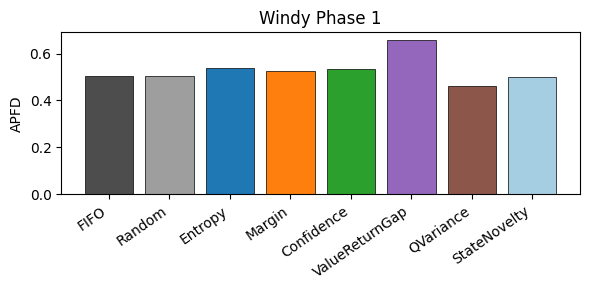

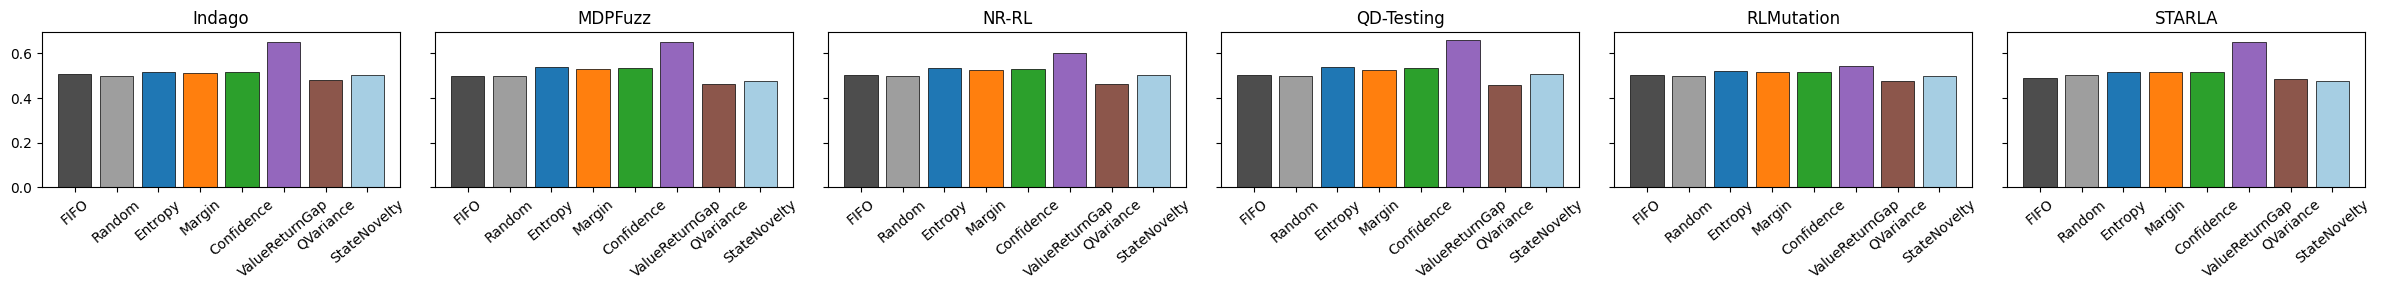

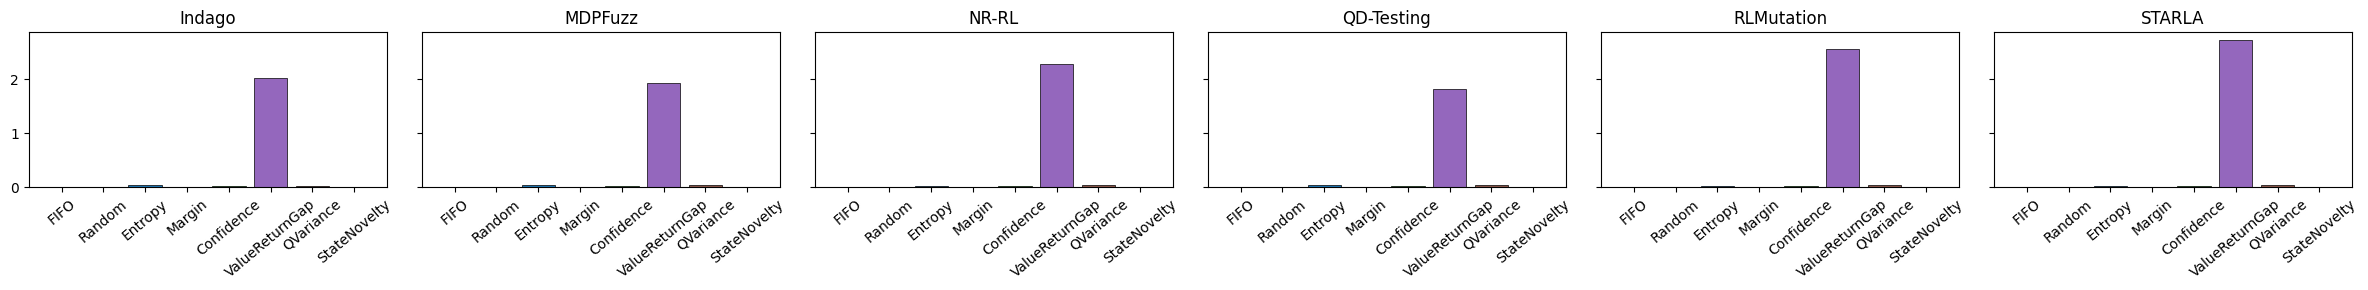


Tables : /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/results/windy/tables
Figures: /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/results/windy/figs


In [31]:
# =============================================================================
# MAIN
# =============================================================================

def main():

    print("=" * 70)
    print("STOCHASTIC WINDY TCP REPLICATION")
    print("=" * 70)

    print("\nRunning Phase 1...")
    phase1_results = run_phase1()

    phase1_agg = summarize_phase1(
        phase1_results
    )

    phase1_stats = phase1_statistics(
        phase1_results
    )

    print("\nRunning Phase 2...")
    phase2_results = run_phase2()

    phase2_agg = summarize_phase2(
        phase2_results
    )

    phase2_stats = phase2_statistics(
        phase2_results
    )

    print("\nGenerating plots...")

    plot_phase1_apfd(
        phase1_agg
    )

    plot_phase2_apfd(
        phase2_agg
    )

    plot_phase2_overhead(
        phase2_agg
    )

    print(
        f"\nTables : {TABLES_DIR}"
    )

    print(
        f"Figures: {FIGS_DIR}"
    )

    return {
        "phase1_results": phase1_results,
        "phase2_results": phase2_results,
    }


if __name__ == "__main__":

    outputs = main()